# Exercise 05 — Karate Club



In [ ]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

from networkx.algorithms import community

G = nx.karate_club_graph()

print("Graph loaded successfully")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Is directed:", G.is_directed())
print("Is connected:", nx.is_connected(G))

print("\nExample node attributes:")
print(list(G.nodes(data=True))[:5])

print("\nExample edge attributes:")
print(list(G.edges(data=True))[:5])

Graph loaded successfully
Nodes: 34
Edges: 78
Is directed: False
Is connected: True

Example node attributes:
[(0, {'club': 'Mr. Hi'}), (1, {'club': 'Mr. Hi'}), (2, {'club': 'Mr. Hi'}), (3, {'club': 'Mr. Hi'}), (4, {'club': 'Mr. Hi'})]

Example edge attributes:
[(0, 1, {'weight': 4}), (0, 2, {'weight': 5}), (0, 3, {'weight': 3}), (0, 4, {'weight': 3}), (0, 5, {'weight': 3})]


## Prepare graph for community detection

The Karate Club graph is already suitable for community detection:

- It is **undirected**, so no weak/strong conversion is needed.
- It is **not bipartite**, so no projection is needed.
- Edges include a weight attribute, which can be used by algorithms that support weighted graphs.
- Nodes include the known club label, which is useful for comparing detected communities with the real split.


##  Community detection method 1: Louvain

Louvain detects communities by optimizing modularity. It is useful here because the Karate Club split is expected to produce dense groups with fewer ties between them.


In [ ]:
louvain_communities = list(community.louvain_communities(G, weight="weight", seed=42))

print("Number of Louvain communities:", len(louvain_communities))
print("Community sizes:", sorted([len(c) for c in louvain_communities], reverse=True))

for i, comm in enumerate(louvain_communities):
    print(f"Community {i}: {sorted(comm)}")

Number of Louvain communities: 4
Community sizes: [14, 10, 6, 4]
Community 0: [1, 2, 3, 7, 12, 13]
Community 1: [0, 4, 5, 6, 10, 11, 16, 17, 19, 21]
Community 2: [24, 25, 28, 31]
Community 3: [8, 9, 14, 15, 18, 20, 22, 23, 26, 27, 29, 30, 32, 33]


##  Community detection method 2: Label propagation

Label propagation detects communities by repeatedly spreading labels through the network. It is a different approach from Louvain because it does not directly optimize modularity.


In [ ]:
label_prop_communities = list(community.asyn_lpa_communities(G, weight="weight", seed=42))

print("Number of label propagation communities:", len(label_prop_communities))
print("Community sizes:", sorted([len(c) for c in label_prop_communities], reverse=True))

for i, comm in enumerate(label_prop_communities):
    print(f"Community {i}: {sorted(comm)}")

Number of label propagation communities: 3
Community sizes: [18, 11, 5]
Community 0: [0, 1, 2, 3, 7, 11, 12, 13, 17, 19, 21]
Community 1: [4, 5, 6, 10, 16]
Community 2: [8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]


##  Modularity

Modularity measures how well a partition separates dense internal connections from sparse external connections.  
Higher modularity usually means a clearer community structure.


In [ ]:
louvain_modularity = community.modularity(G, louvain_communities, weight="weight")
label_prop_modularity = community.modularity(G, label_prop_communities, weight="weight")

modularity_df = pd.DataFrame({
    "method": ["Louvain", "Label propagation"],
    "number_of_communities": [len(louvain_communities), len(label_prop_communities)],
    "community_sizes": [
        sorted([len(c) for c in louvain_communities], reverse=True),
        sorted([len(c) for c in label_prop_communities], reverse=True)
    ],
    "modularity": [louvain_modularity, label_prop_modularity]
})

modularity_df

,method,number_of_communities,community_sizes,modularity
0,Louvain,4,"[14, 10, 6, 4]",0.426622
1,Label propagation,3,"[18, 11, 5]",0.434521


##  Compare detected communities with the known split

The graph includes the real faction label in the `club` node attribute.  
Here we compare the Louvain communities with the known split: `Mr. Hi` and `Officer`.


In [ ]:
def make_partition_map(communities):
    partition = {}
    for i, comm in enumerate(communities):
        for node in comm:
            partition[node] = i
    return partition

louvain_partition = make_partition_map(louvain_communities)
label_partition = make_partition_map(label_prop_communities)

comparison_df = pd.DataFrame({
    "node": list(G.nodes()),
    "known_club": [G.nodes[n]["club"] for n in G.nodes()],
    "louvain_community": [louvain_partition[n] for n in G.nodes()],
    "label_prop_community": [label_partition[n] for n in G.nodes()]
}).sort_values("node")

comparison_df.head(34)

,node,known_club,louvain_community,label_prop_community
0,0,Mr. Hi,1,0
1,1,Mr. Hi,0,0
2,2,Mr. Hi,0,0
3,3,Mr. Hi,0,0
4,4,Mr. Hi,1,1
5,5,Mr. Hi,1,1
6,6,Mr. Hi,1,1
7,7,Mr. Hi,0,0
8,8,Mr. Hi,3,2
9,9,Officer,3,2


In [ ]:
known_vs_louvain = pd.crosstab(
    comparison_df["known_club"],
    comparison_df["louvain_community"],
    rownames=["Known club"],
    colnames=["Louvain community"]
)

known_vs_label = pd.crosstab(
    comparison_df["known_club"],
    comparison_df["label_prop_community"],
    rownames=["Known club"],
    colnames=["Label propagation community"]
)

print("Known split vs Louvain communities")
display(known_vs_louvain)

print("\nKnown split vs label propagation communities")
display(known_vs_label)

Known split vs Louvain communities


Louvain community,0,1,2,3
Known club,,,,
Mr. Hi,6,10,0,1
Officer,0,0,4,13



Known split vs label propagation communities


Label propagation community,0,1,2
Known club,,,
Mr. Hi,11,5,1
Officer,0,0,17


##  Identify bridge nodes between communities

A bridge node is defined here as a node that has at least one edge to a node in a different detected community.  
We use the Louvain partition for this analysis and rank bridge nodes by:

1. number of different outside communities they connect to,
2. betweenness centrality,
3. degree.


In [ ]:
betweenness = nx.betweenness_centrality(G, weight=None)

bridge_rows = []

for node in G.nodes():
    own_comm = louvain_partition[node]
    neighbor_communities = {
        louvain_partition[nbr]
        for nbr in G.neighbors(node)
        if louvain_partition[nbr] != own_comm
    }

    if len(neighbor_communities) > 0:
        bridge_rows.append({
            "node": node,
            "club": G.nodes[node]["club"],
            "louvain_community": own_comm,
            "outside_communities_connected": sorted(neighbor_communities),
            "number_of_outside_communities": len(neighbor_communities),
            "degree": G.degree(node),
            "betweenness": betweenness[node]
        })

bridge_df = pd.DataFrame(bridge_rows).sort_values(
    ["number_of_outside_communities", "betweenness", "degree"],
    ascending=[False, False, False]
)

bridge_df.head(10)

,node,club,louvain_community,outside_communities_connected,number_of_outside_communities,degree,betweenness
0,0,Mr. Hi,1,"[0, 2, 3]",3,16,0.437635
20,33,Officer,3,"[0, 1, 2]",3,17,0.304075
2,2,Mr. Hi,0,"[1, 2, 3]",3,10,0.143657
19,32,Officer,3,"[0, 2]",2,12,0.145247
18,31,Officer,2,"[1, 3]",2,6,0.138276
5,8,Mr. Hi,3,"[0, 1]",2,5,0.055927
1,1,Mr. Hi,0,"[1, 3]",2,9,0.053937
8,13,Mr. Hi,0,"[1, 3]",2,5,0.045863
10,19,Mr. Hi,1,"[0, 3]",2,3,0.032475
15,27,Officer,3,"[0, 2]",2,4,0.022333


##  Visualization of Louvain communities

The graph is visualized using the Louvain partition.  
Node colors represent detected communities, and node labels show member IDs.


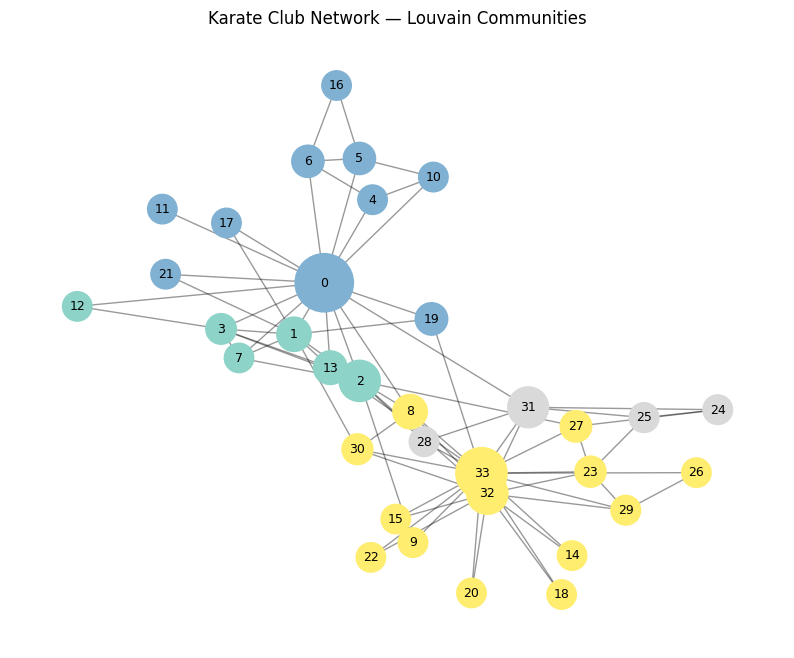

In [ ]:
pos = nx.spring_layout(G, seed=42)

node_colors = [louvain_partition[n] for n in G.nodes()]
node_sizes = [450 + betweenness[n] * 3000 for n in G.nodes()]

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(G, pos, alpha=0.4)
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    cmap=plt.cm.Set3
)
nx.draw_networkx_labels(G, pos, font_size=9)

plt.title("Karate Club Network — Louvain Communities")
plt.axis("off")
plt.show()

##  Boundary members visualization

This visualization highlights bridge nodes between Louvain communities.  



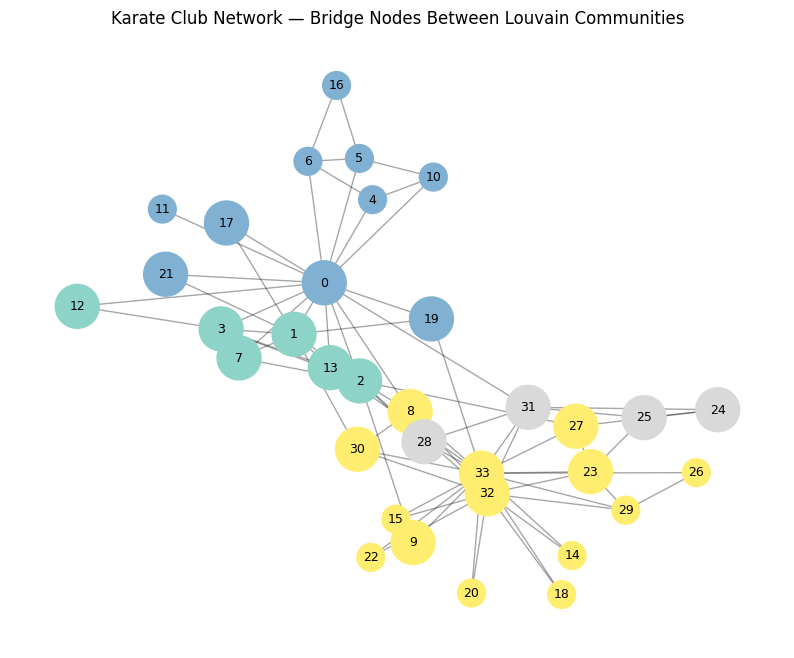

In [ ]:
bridge_nodes = set(bridge_df["node"])

bridge_node_sizes = []
for n in G.nodes():
    if n in bridge_nodes:
        bridge_node_sizes.append(1000)
    else:
        bridge_node_sizes.append(400)

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(G, pos, alpha=0.35)
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=bridge_node_sizes,
    cmap=plt.cm.Set3
)
nx.draw_networkx_labels(G, pos, font_size=9)

plt.title("Karate Club Network — Bridge Nodes Between Louvain Communities")
plt.axis("off")
plt.show()

## Interpretation

Both Louvain and label propagation detect community structure in the Karate Club network, but they do not necessarily produce the same number of communities. This is expected because Louvain optimizes modularity, while label propagation spreads labels locally through the graph. The detected communities broadly correspond to the known split between the `Mr. Hi` and `Officer` factions, although the algorithms may divide the club into more than two subgroups. This suggests that the real split was not only a simple two-sided division, but also contained smaller local clusters inside each side. Bridge nodes such as nodes 0, 33, 2, 32, and 31 connect across detected communities and can be interpreted as boundary members or structurally important connectors between factions.
